# Viz of Evolution data

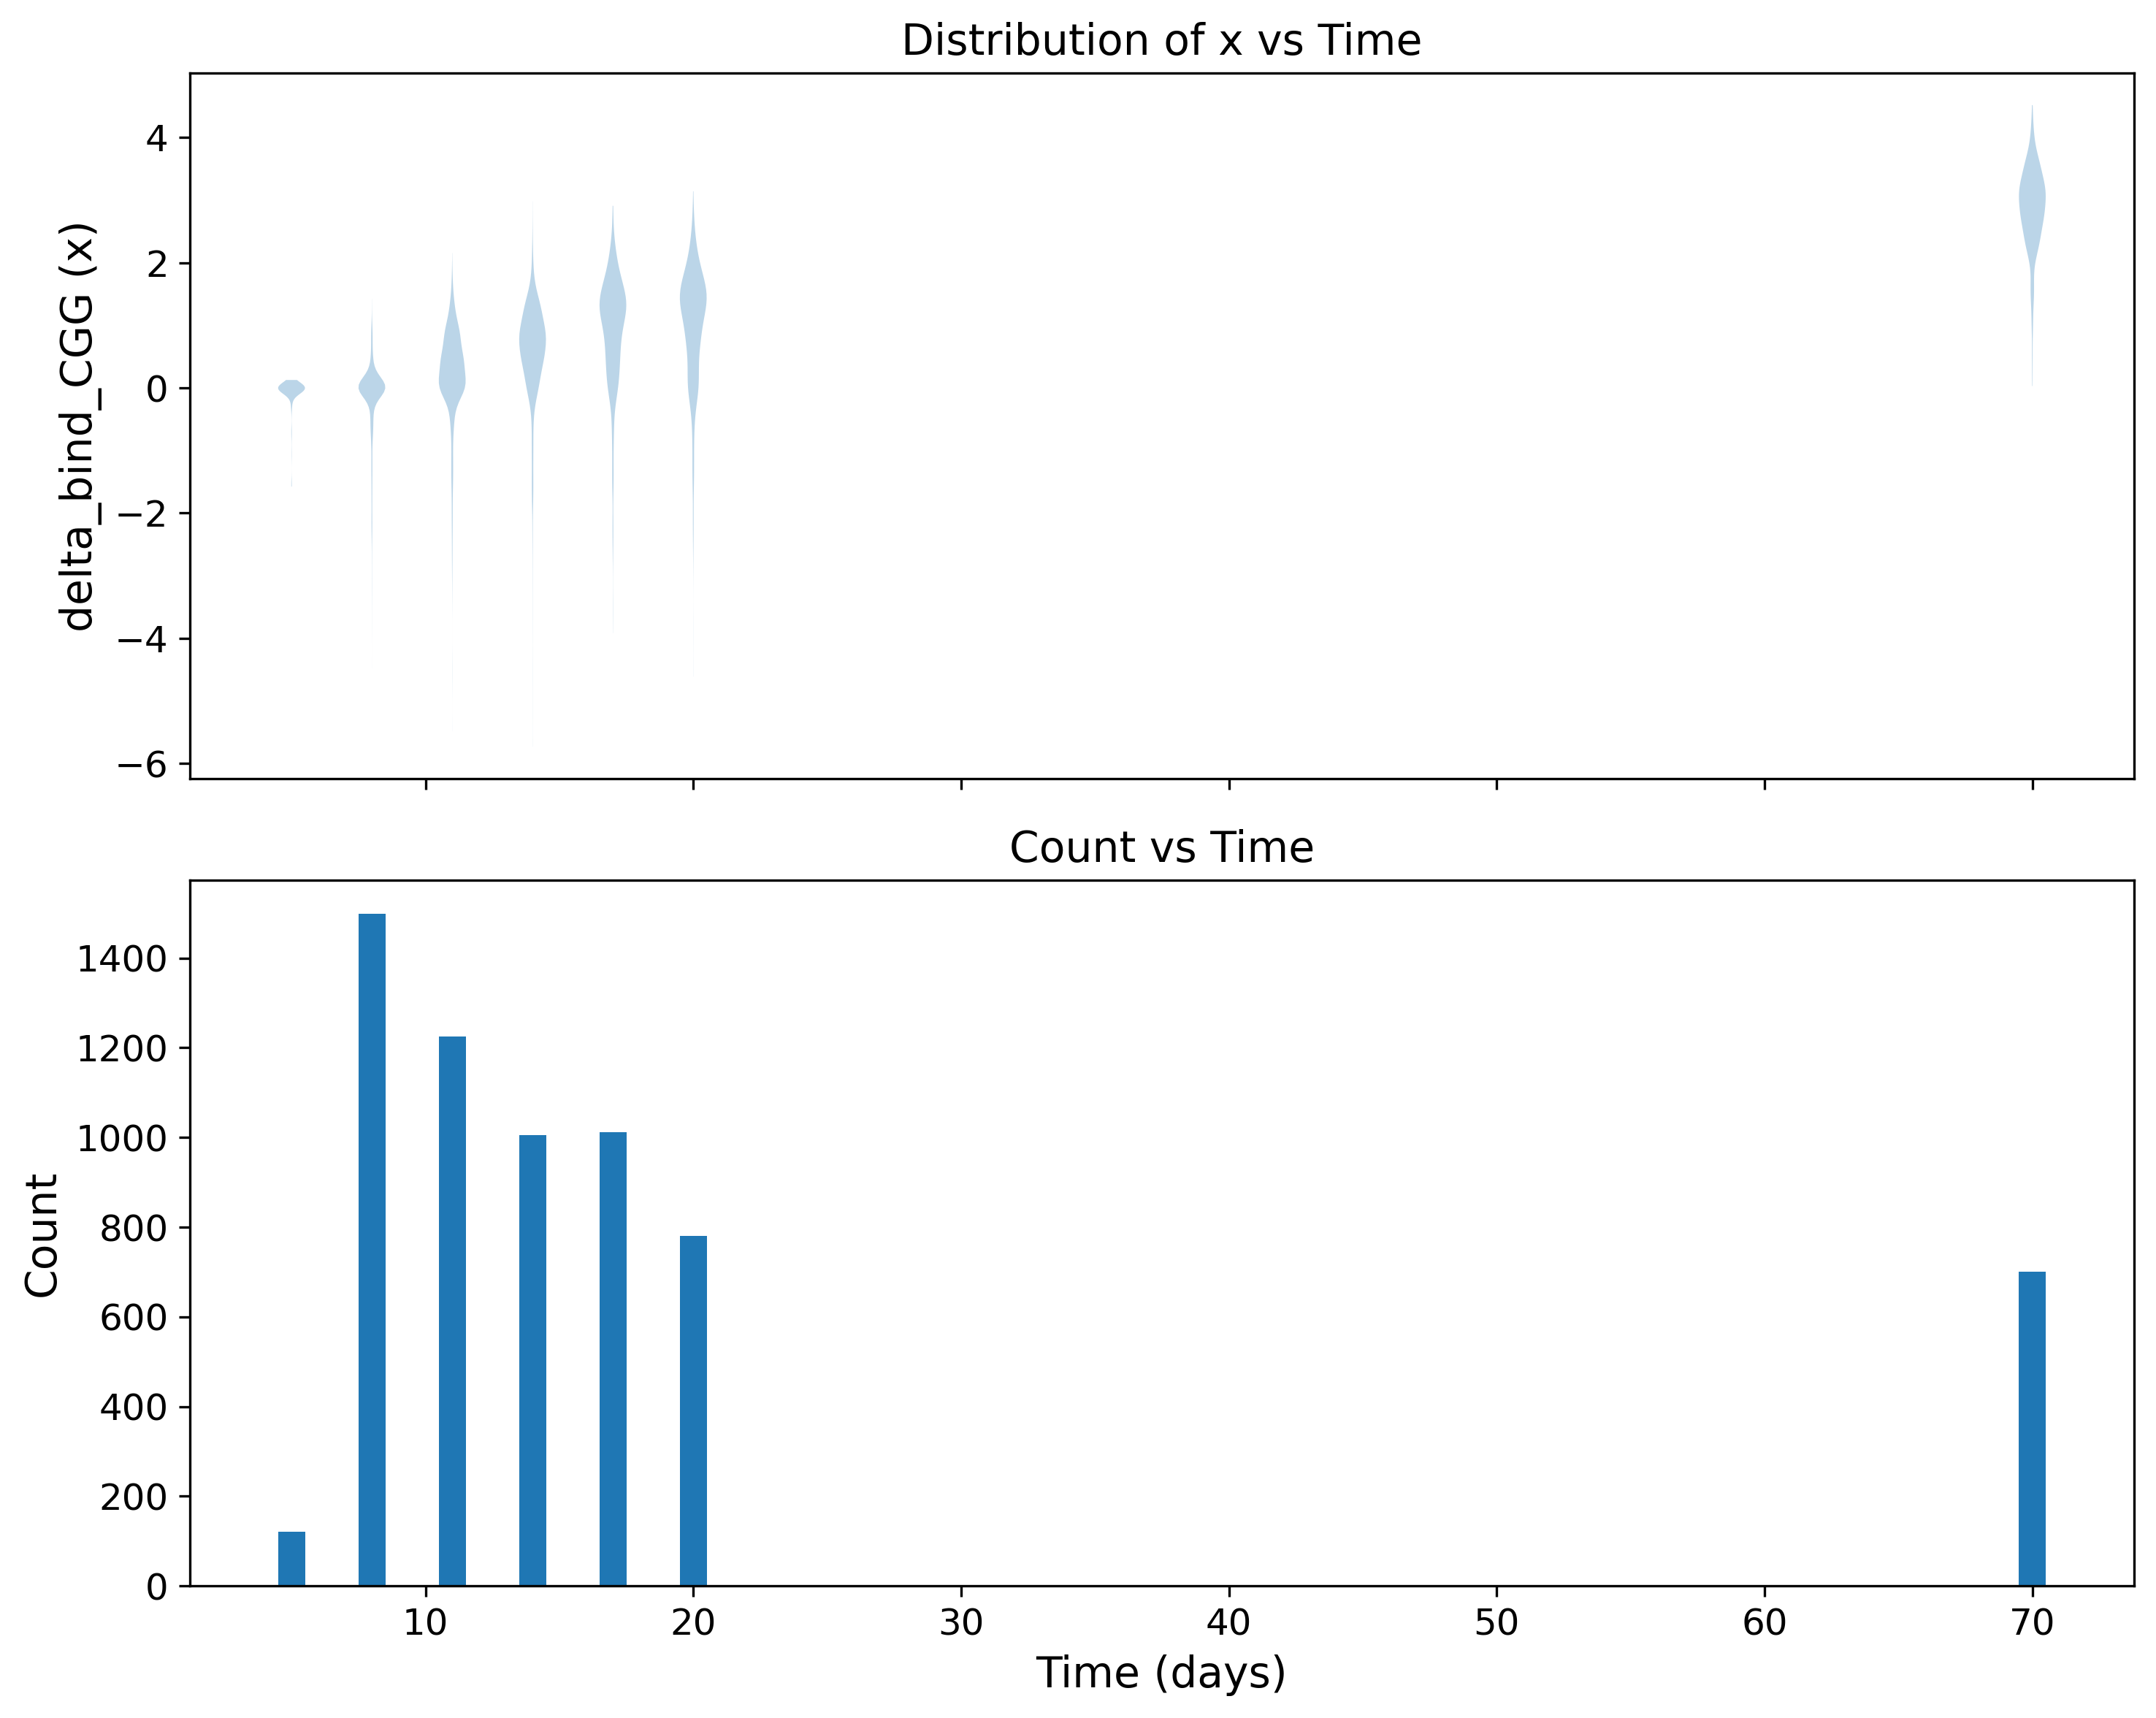

In [297]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file
data_csv_path = "data.csv"
df = pd.read_csv(data_csv_path, keep_default_na=False)[["time (days)", "mouse", "delta_bind_CGG", "mutations_H", "mutations_L", "n_mutations_H", "n_mutations_L"]]

# Preprocess
df["time (days)"] = df["time (days)"].astype(np.float64)
df.rename(columns={"time (days)": "t", "delta_bind_CGG": "x"}, inplace=True)
assert df.x.isna().sum() == 0

# Group for visualization
count_vs_time = df.groupby("t").size()
# Group for visualization (fixed)
x_vs_time = df.groupby("t")["x"].apply(list)
positions = x_vs_time.index.to_numpy()
data = x_vs_time.tolist()

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Distribution of x vs time (violin plot)
axes[0].violinplot(data, positions=positions, widths=1.0, showmeans=False, showmedians=False, showextrema=False)
axes[0].set_ylabel("delta_bind_CGG (x)")
axes[0].set_title("Distribution of x vs Time")

# Count vs time (bar plot)
axes[1].bar(count_vs_time.index, count_vs_time.values, width=1.0)
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Time (days)")
axes[1].set_title("Count vs Time")

plt.tight_layout()
plt.show()


In [298]:
data_csv_path = "data.csv"

df = pd.read_csv(data_csv_path, keep_default_na=False)
df

,barcode,is_cell_H,contig_id_H,high_confidence_H,length_H,chain_H,v_gene_H,d_gene_H,j_gene_H,c_gene_H,...,n_mutations_L,delta_bind_CGG_L,delta_expr_L,delta_bind_CGG,delta_expr,n_mutations,nt_seq,time (days),mouse,n_mutations_chunked
0,AAACCTGAGAATCTCC-1,True,AAACCTGAGAATCTCC-1_contig_2,True,527,IGH,IGHV3-8,,IGHJ1,IGHG2B,...,1,0.80414,0.03813,0.80353,0.01580,2,GAGGTGCAGCTTCAGGAGTCAGGACCTAGCCTCGTGAAACCTTCTC...,14,D14M1,2
1,AAACCTGAGCCGCCTA-1,True,AAACCTGAGCCGCCTA-1_contig_2,True,542,IGH,IGHV3-8,,IGHJ1,IGHG1,...,0,0.00000,0.00000,0.00000,0.00000,0,GAGGTGCAGCTTCAGGAGTCAGGACCTAGCCTCGTGAAACCTTCTC...,8,D8M1,0
2,AAACCTGCAGTACACT-1,True,AAACCTGCAGTACACT-1_contig_1,True,671,IGH,IGHV3-8,,IGHJ1,IGHM,...,0,0.00000,0.00000,0.00000,0.00000,0,GAGGTGCAGCTTCAGGAGTCAGGACCTAGCCTCGTGAAACCTTCTC...,8,D8M4,0
3,AAACCTGGTCCGACGT-1,True,AAACCTGGTCCGACGT-1_contig_1,True,661,IGH,IGHV3-8,,IGHJ1,IGHM,...,1,0.80414,0.03813,0.80414,0.03813,1,GAGGTGCAGCTTCAGGAGTCAGGACCTAGCCTCGTGAAACCTTCTC...,11,D11M1,1
4,AAACCTGTCTTAACCT-1,True,AAACCTGTCTTAACCT-1_contig_1,True,672,IGH,IGHV3-8,,IGHJ1,IGHM,...,0,0.00000,0.00000,0.00000,0.00000,0,GAGGTGCAGCTTCAGGAGTCAGGACCTAGCCTCGTGAAACCTTCTC...,11,D11M1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6336,TTTGCGCAGATCCCGC-1,True,TTTGCGCAGATCCCGC-1_contig_1,True,546,IGH,IGHV3-8,,IGHJ1,IGHG1,...,6,1.80990,-0.67323,3.12047,-1.10166,14,GAGGTGCAGCTTCAGGAGTCAGGACCTAGCCTCGTGAAACCTTCTC...,70,D70M5,8+
6337,TTTGCGCAGTGCTGCC-1,True,TTTGCGCAGTGCTGCC-1_contig_2,True,553,IGH,IGHV3-8,,IGHJ1,IGHG1,...,5,1.61240,-0.06129,3.48925,-0.09376,11,GAGGTGCAGCTTCAGGAGTCAGGACCTAGCCTCGTGAAACCTTCTC...,70,D70M9,8+
6338,TTTGGTTTCAGCCTAA-1,True,TTTGGTTTCAGCCTAA-1_contig_2,True,460,IGH,IGHV3-8,,IGHJ1,,...,7,1.80824,-0.01487,3.64011,-0.16171,14,GAGGTGCAGCTTCAGGAGTCAGGACCTAGCCTCGTGAAACCTTCTC...,70,D70M9,8+
6339,TTTGGTTTCTCCCTGA-1,True,TTTGGTTTCTCCCTGA-1_contig_2,True,473,IGH,IGHV3-8,,IGHJ1,,...,7,1.07204,-0.02940,2.35357,-0.18553,11,GAGGTGCAGCTTCAGGAGTCAGGACCTAGCCTCGTGAAACCTTCTC...,70,D70M6,8+


In [299]:
# # Concatenate CDRs: H then L
# cdrH = df["cdr1_H"].fillna("") + df["cdr2_H"].fillna("") + df["cdr3_H"].fillna("")
# cdrL = df["cdr1_L"].fillna("") + df["cdr2_L"].fillna("") + df["cdr3_L"].fillna("")

# df["cdr_HL"] = cdrH + cdrL
# df["cdr_HL_len"] = df["cdr_HL"].str.len()

# # Quick sanity: show basic stats and a few examples
# print(df["cdr_HL_len"].describe())
# print(df[["cdr1_H","cdr2_H","cdr3_H","cdr1_L","cdr2_L","cdr3_L","cdr_HL_len"]].head())

def concat_mutations(row):
    mut_h = str(row["mutations_H"]).strip()
    mut_l = str(row["mutations_L"]).strip()

    # Treat NaN or "nan" as empty
    if mut_h.lower() == "nan":
        mut_h = ""
    if mut_l.lower() == "nan":
        mut_l = ""

    if mut_h and mut_l:
        return f"{mut_h},{mut_l}"
    elif mut_h:
        return mut_h
    elif mut_l:
        return mut_l
    else:
        return ""

df["all_mut"] = df.apply(concat_mutations, axis=1)

df["all_mut"]


0                                         Y67(H)S,A40(L)G
1                                                        
2                                                        
3                                                 A40(L)G
4                                                        
                              ...                        
6336    T22(H)S,T26(H)A,D28(H)G,G47(H)R,Y88(H)N,T96(H)...
6337    D28(H)A,G47(H)E,S57(H)N,S64(H)R,I76(H)F,N92(H)...
6338    D28(H)A,G47(H)E,S57(H)N,S64(H)R,I76(H)F,N92(H)...
6339    D28(H)V,S57(H)N,A105(H)G,V117(H)I,S7(L)P,Y42(L...
6340    K14(H)T,D28(H)A,K72(H)I,T101(H)I,A57(L)T,Q105(...
Name: all_mut, Length: 6341, dtype: object

In [300]:

data_csv_path = "final_variant_scores.csv"
df_dms = pd.read_csv(data_csv_path)
allowed_annotations = ['CDRH1', 'CDRH2', 'CDRH3', 'CDRL1', 'CDRL2', 'CDRL3']
df_dms = df_dms[df_dms['annotation'].isin(allowed_annotations)]
df_dms['annotation'].unique()

array(['CDRH1', 'CDRH2', 'CDRH3', 'CDRL1', 'CDRL2', 'CDRL3'], dtype=object)

In [301]:
# Filter to CDR rows only


df_dms["delta_bind_CGG"]=df_dms["delta_bind_CGG"]*np.log(10)
df_dms['position'] = df_dms['position'] - 1

dict_dms = dict(zip(df_dms["mutation"], df_dms["delta_bind_CGG"]))
dict_mutations=dict(zip(df_dms["mutation"], df_dms["position"]))

positions=df_dms.position.unique()

# print(df_dms.annotation.unique())
# # Keep only unique (position, annotation) pairs
# pos_annotation_dict = (
#     df_dms.drop_duplicates(subset=["position", "annotation"])
#       .set_index("position")["annotation"]
#       .to_dict()
# )

# print(pos_annotation_dict)
# cdr_positions = (
#     df_dms[df_dms["annotation"].str.contains("CDR", na=False)]
#     .drop_duplicates(subset=["position"])
#     [["position"]]
#     .to_records(index=False)
#     .tolist()
# )
# cdr_positions=[pos[0] for pos in cdr_positions]
# print(cdr_positions)#absolute position
# #i need index of cdr_positions inside position array
# cdr_positions_relative = [np.where(positions == p)[0][0] for p in cdr_positions]

# print(cdr_positions_relative)



In [302]:
import re
import pandas as pd
import numpy as np


def effects_by_position(df, positions, dict_dms):
    """
    Build a new DataFrame with:
      - columns: 'time (days)', 'all_mut', and one column per site in `positions`
      - values: effect (from dict_dms) added into the matching site column for each mutation in 'all_mut'
    """
    # Base frame
    out = df[["time (days)", "all_mut"]].copy()

    # Ensure numeric column names exactly as the numbers in `positions`
    pos_cols = [int(p) for p in positions]
    for p in pos_cols:
        out[p] = 0.0

    # Row-wise fill
    for idx, muts in out["all_mut"].items():
        if pd.isna(muts) or not str(muts).strip():
            continue
        for m in str(muts).split(","):
            m = m.strip()
            if not m:
                continue
            # parse position
            try:
                mpos = dict_mutations[m]
            except:
                continue
            pos = int(mpos)
            if pos in pos_cols:
                # add effect if present, else 0
                eff = dict_dms.get(m, 0.0)
                out.at[idx, pos] += eff

    return out
result_df = effects_by_position(df, positions, dict_dms)
result_df

,time (days),all_mut,25,26,27,28,29,30,31,32,...,178,215,216,217,218,219,220,221,222,223
0,14,"Y67(H)S,A40(L)G",0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
1,8,,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
2,8,,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
3,11,A40(L)G,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
4,11,,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6336,70,"T22(H)S,T26(H)A,D28(H)G,G47(H)R,Y88(H)N,T96(H)...",0.0,1.607458,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,1.979417,0.028345,0.0,0.0,1.044545,0.0
6337,70,"D28(H)A,G47(H)E,S57(H)N,S64(H)R,I76(H)F,N92(H)...",0.0,1.978082,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.875673,0.0,0.0,0.000000,1.010927,0.0,0.0,0.000000,0.0
6338,70,"D28(H)A,G47(H)E,S57(H)N,S64(H)R,I76(H)F,N92(H)...",0.0,1.978082,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.875673,0.0,0.0,0.000000,1.010927,0.0,0.0,0.000000,0.0
6339,70,"D28(H)V,S57(H)N,A105(H)G,V117(H)I,S7(L)P,Y42(L...",0.0,1.781809,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.875673,0.0,0.0,1.979417,0.000000,0.0,0.0,0.000000,0.0


In [303]:
avg_by_time = result_df.groupby("time (days)").mean(numeric_only=True).reset_index()
avg_by_time['time']=avg_by_time['time (days)']*2
avg_by_time.to_csv("avg_binding_site_time.csv", index=False)

print(avg_by_time)

   time (days)        25        26        27        28        29        30  \
0            5  0.000000  0.000000  0.000000  0.000000  0.000000 -0.000097   
1            8  0.000000  0.001496  0.001249 -0.001154 -0.000124 -0.000452   
2           11 -0.000382  0.023511  0.000129 -0.003994 -0.000096 -0.000012   
3           14 -0.000282  0.055951  0.000900 -0.000487  0.000057 -0.000180   
4           17 -0.000840  0.084535  0.001166 -0.003340 -0.000198  0.000006   
5           20 -0.001088  0.084743  0.001629 -0.000416  0.000028 -0.000322   
6           70  0.000000  1.532835  0.007213 -0.007475 -0.000509 -0.000093   

         31        32        49  ...       215       216       217       218  \
0  0.000000  0.000000  0.000000  ...  0.007297  0.000000  0.000000  0.000000   
1 -0.011833 -0.039791 -0.015219  ...  0.007010 -0.002602 -0.027000  0.021480   
2 -0.012851 -0.026615 -0.026802  ...  0.018600 -0.003929 -0.021985  0.201433   
3 -0.013456 -0.031140 -0.012721  ...  0.099264 -0.00223

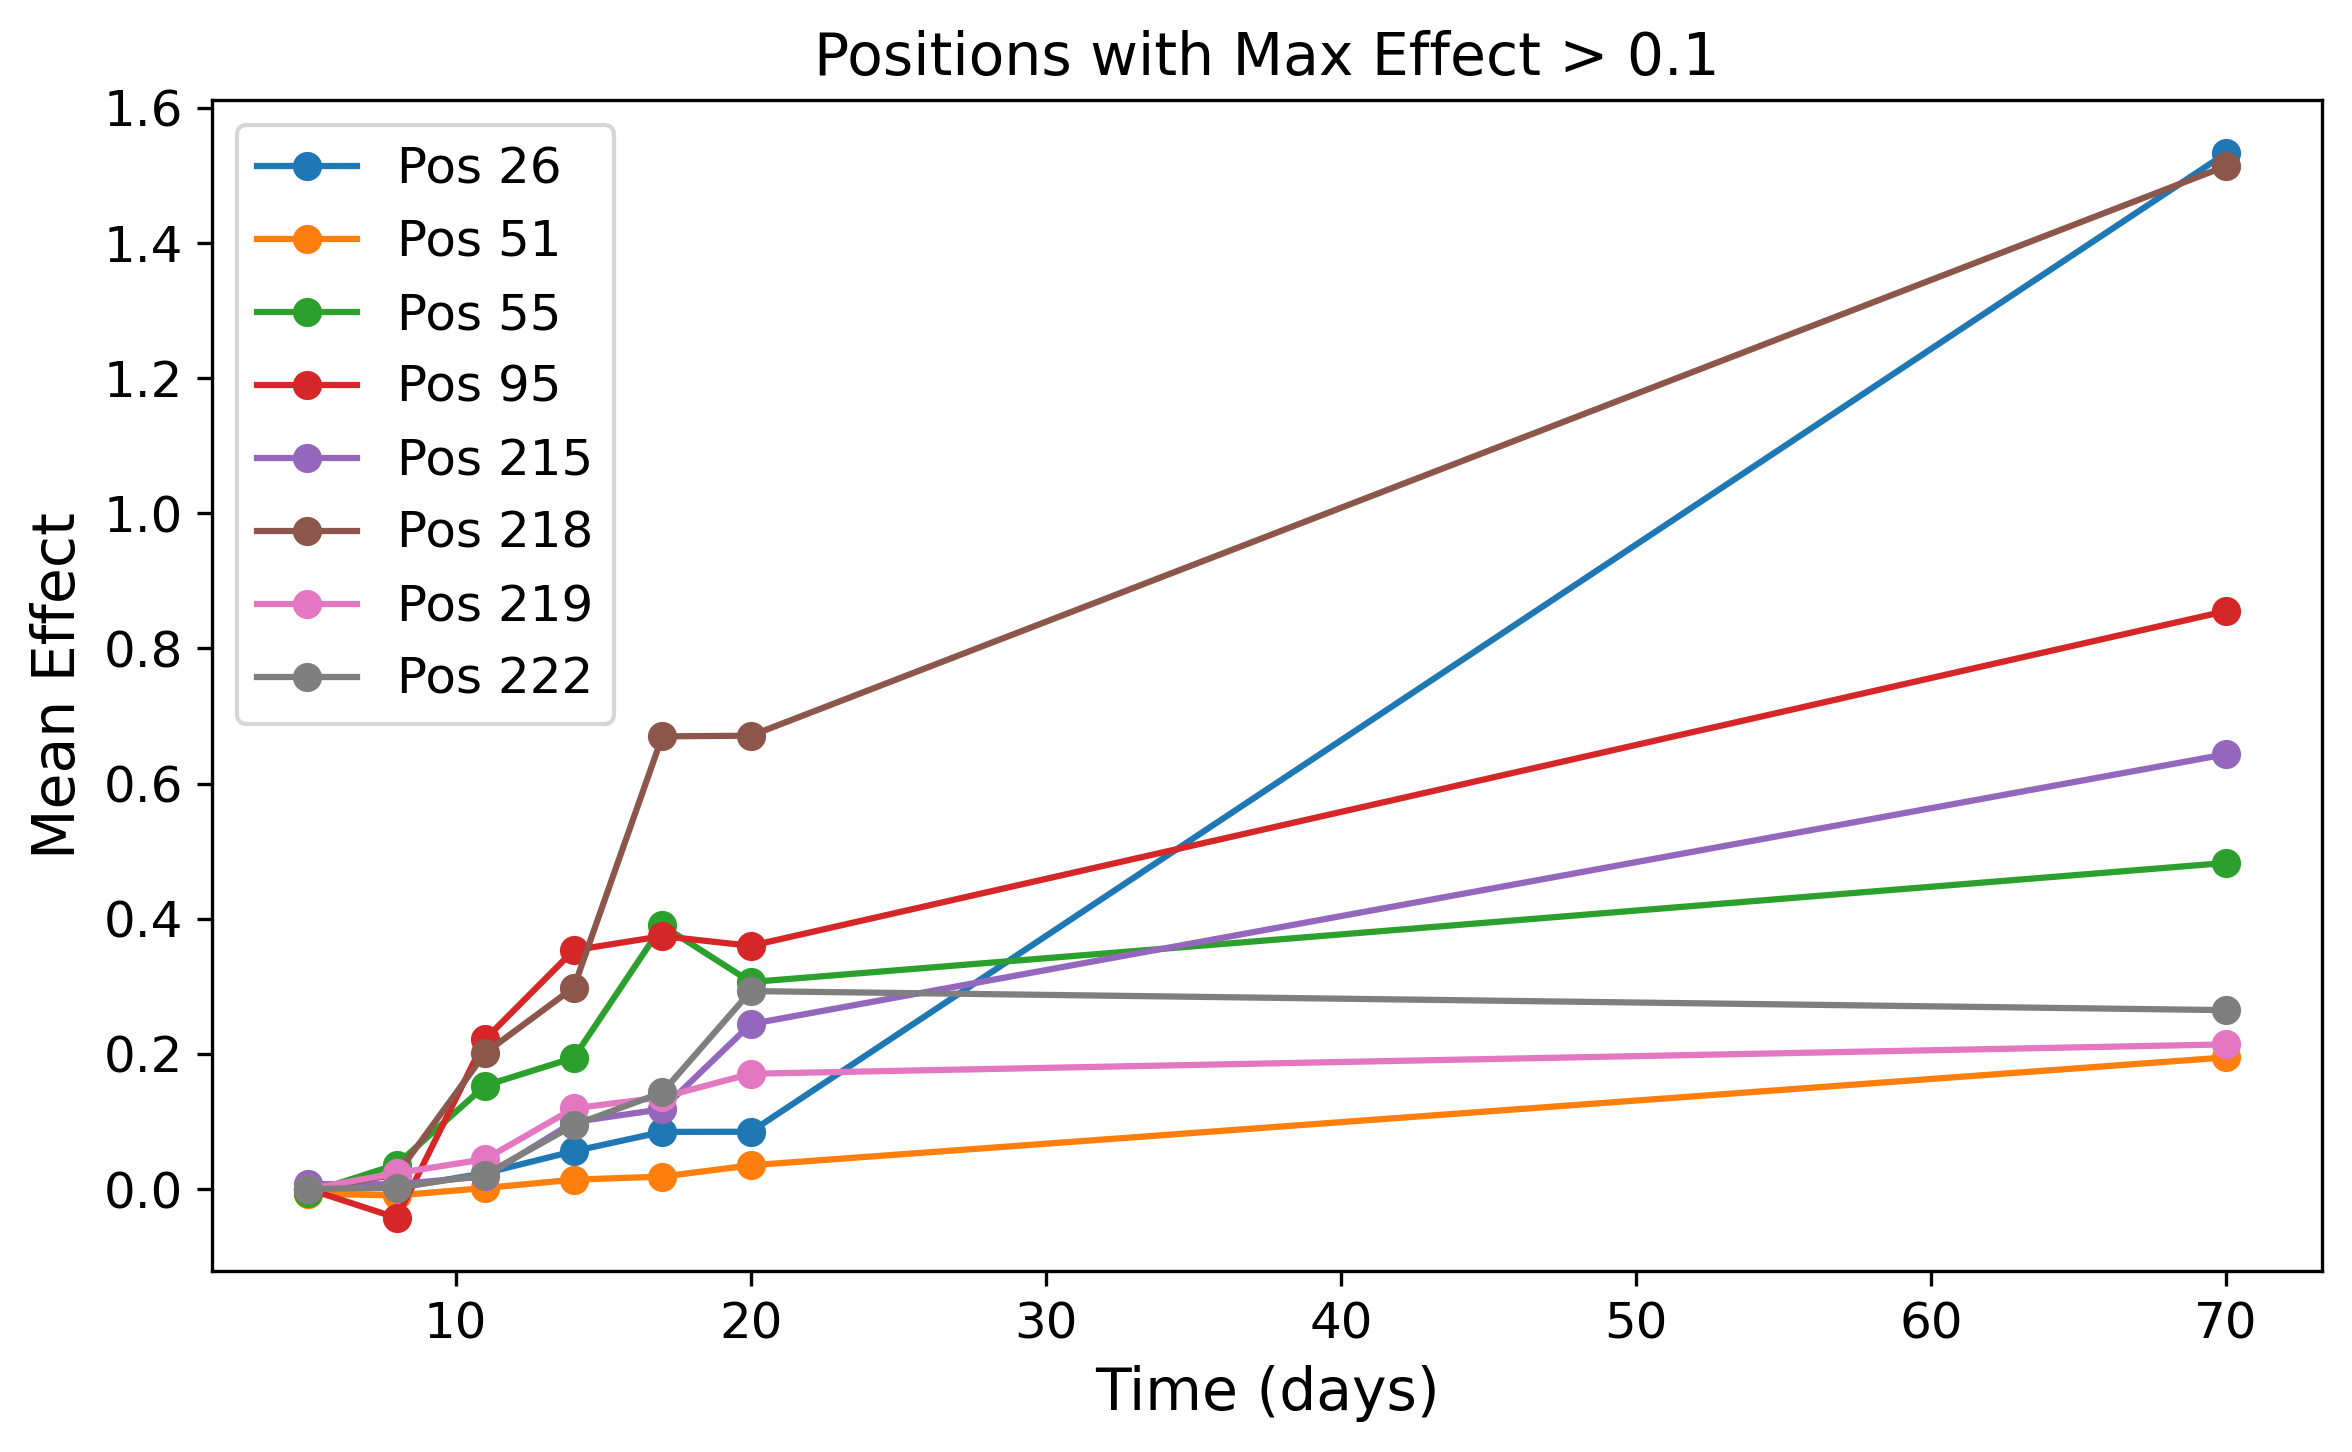

In [304]:
import matplotlib.pyplot as plt

# Filter positions based on max value
pos_cols = [c for c in avg_by_time.columns if isinstance(c, (int, float))]  # numeric position columns
pos_to_plot = [p for p in pos_cols if avg_by_time[p].max() > 0.05]

# Plot each selected position vs time
plt.figure(figsize=(8, 5))
for p in pos_to_plot:
    plt.plot(avg_by_time["time (days)"], avg_by_time[p], marker="o", label=f"Pos {p}")

plt.xlabel("Time (days)")
plt.ylabel("Mean Effect")
plt.title("Positions with Max Effect > 0.1")
plt.legend()
plt.tight_layout()
plt.show()


# Filter on CDR

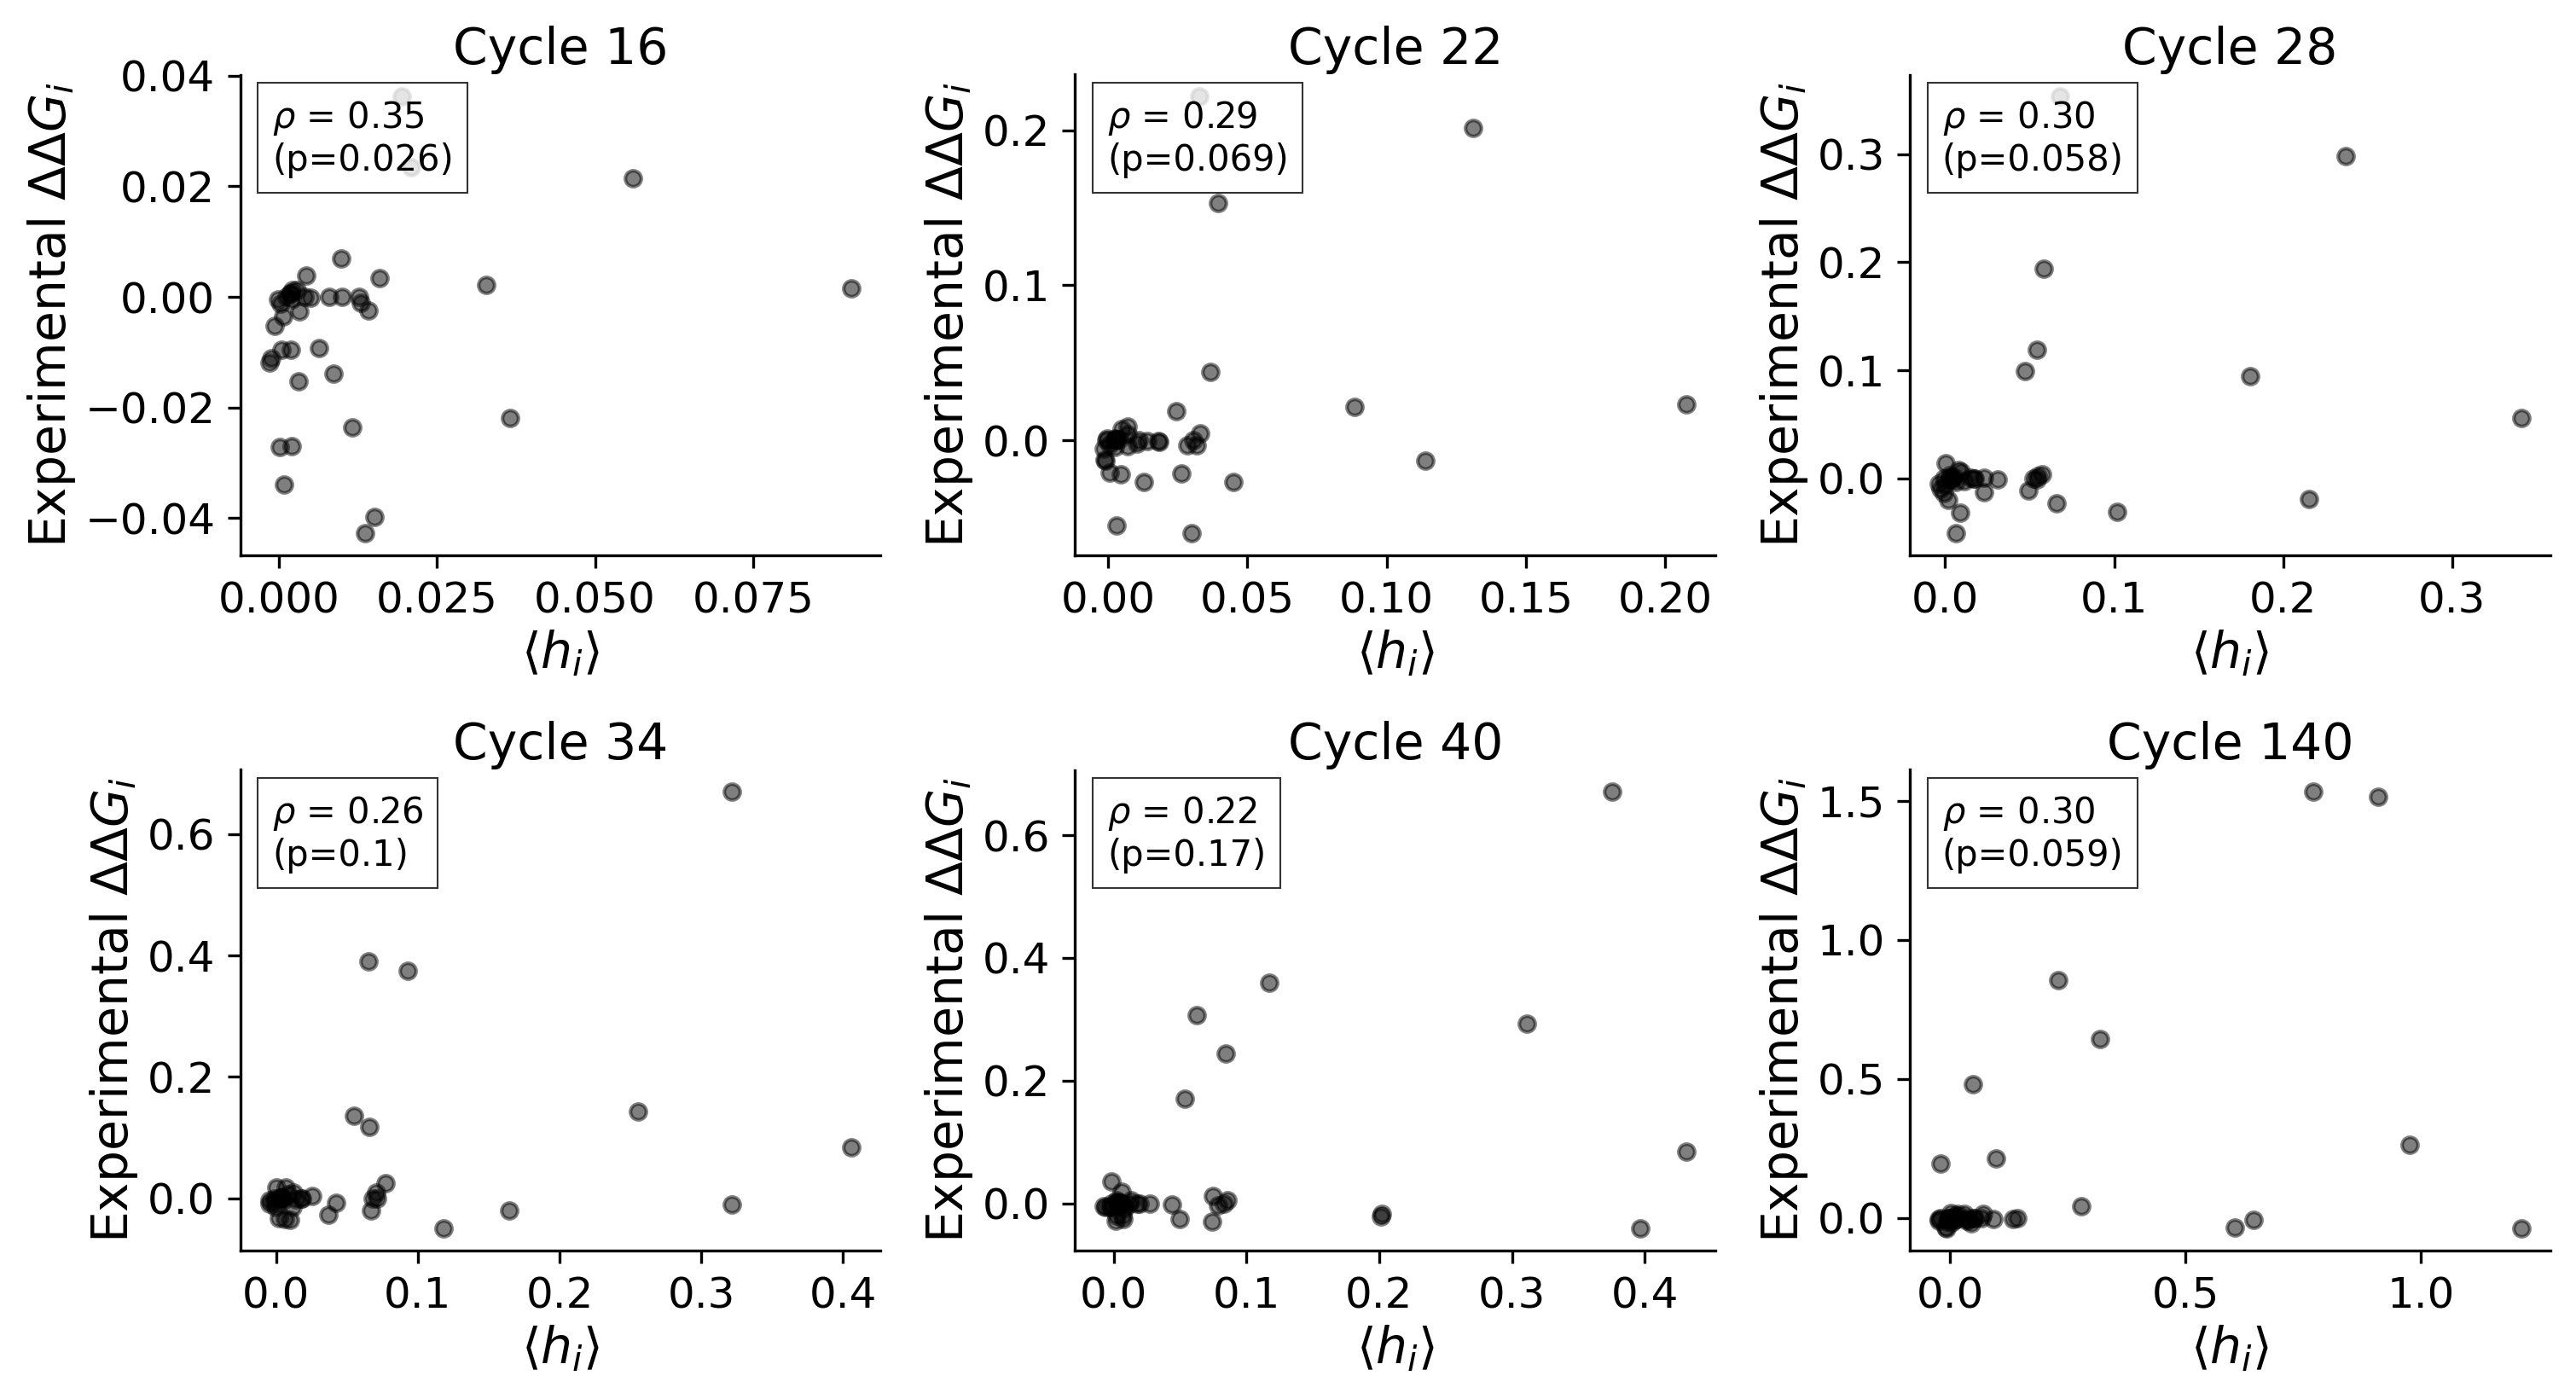

In [305]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
import pandas as pd

# Load data
df_out = pd.read_csv('../stochastic/mean_hi_stochastic.csv')
times = sorted(df_out["time"].unique())[1:]

# PRL figure style
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 300,
    "savefig.dpi": 300
})

# Arrange in grid: 3 plots per row
ncols = 3
nrows = int(np.ceil(len(times) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4*ncols, 2.8*nrows))
axes = np.atleast_2d(axes)  # always 2D array

for idx, t in enumerate(times):
    ax = axes[idx // ncols, idx % ncols]

    # Filter data for time t
    sub = df_out[(df_out["time"] == t) & (df_out["mean_hi"] != 0)]
    positions = sub["position"].values

    # Match values from avg_by_time
    avg_vals = avg_by_time.loc[avg_by_time["time"] == t, np.array(positions)]
    if not avg_vals.empty:
        avg_vals = avg_vals.iloc[0].values
    else:
        avg_vals = [0] * len(positions)

    # Scatter plot
    ax.scatter(sub["mean_hi"], avg_vals, s=20, c="black", alpha=0.5)
    ax.set_xlabel(r"$\langle h_i \rangle$", labelpad=2)
    ax.set_ylabel(r"Experimental $\Delta \Delta G_i$", labelpad=2)
    ax.set_title(f"Cycle {t}", pad=3)

    # Remove extra spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Spearman correlation
    rho, pval = spearmanr(sub["mean_hi"], avg_vals)
    # rho, pval = pearsonr(sub["mean_hi"], avg_vals)

    ax.text(
        0.05, 0.95,
        rf"$\rho$ = {rho:.2f}" + f"\n(p={pval:.2g})",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black", linewidth=0.5)
    )

# Remove unused axes if times not divisible by ncols
for idx in range(len(times), nrows*ncols):
    fig.delaxes(axes[idx // ncols, idx % ncols])

plt.tight_layout(pad=1.0)
plt.show()


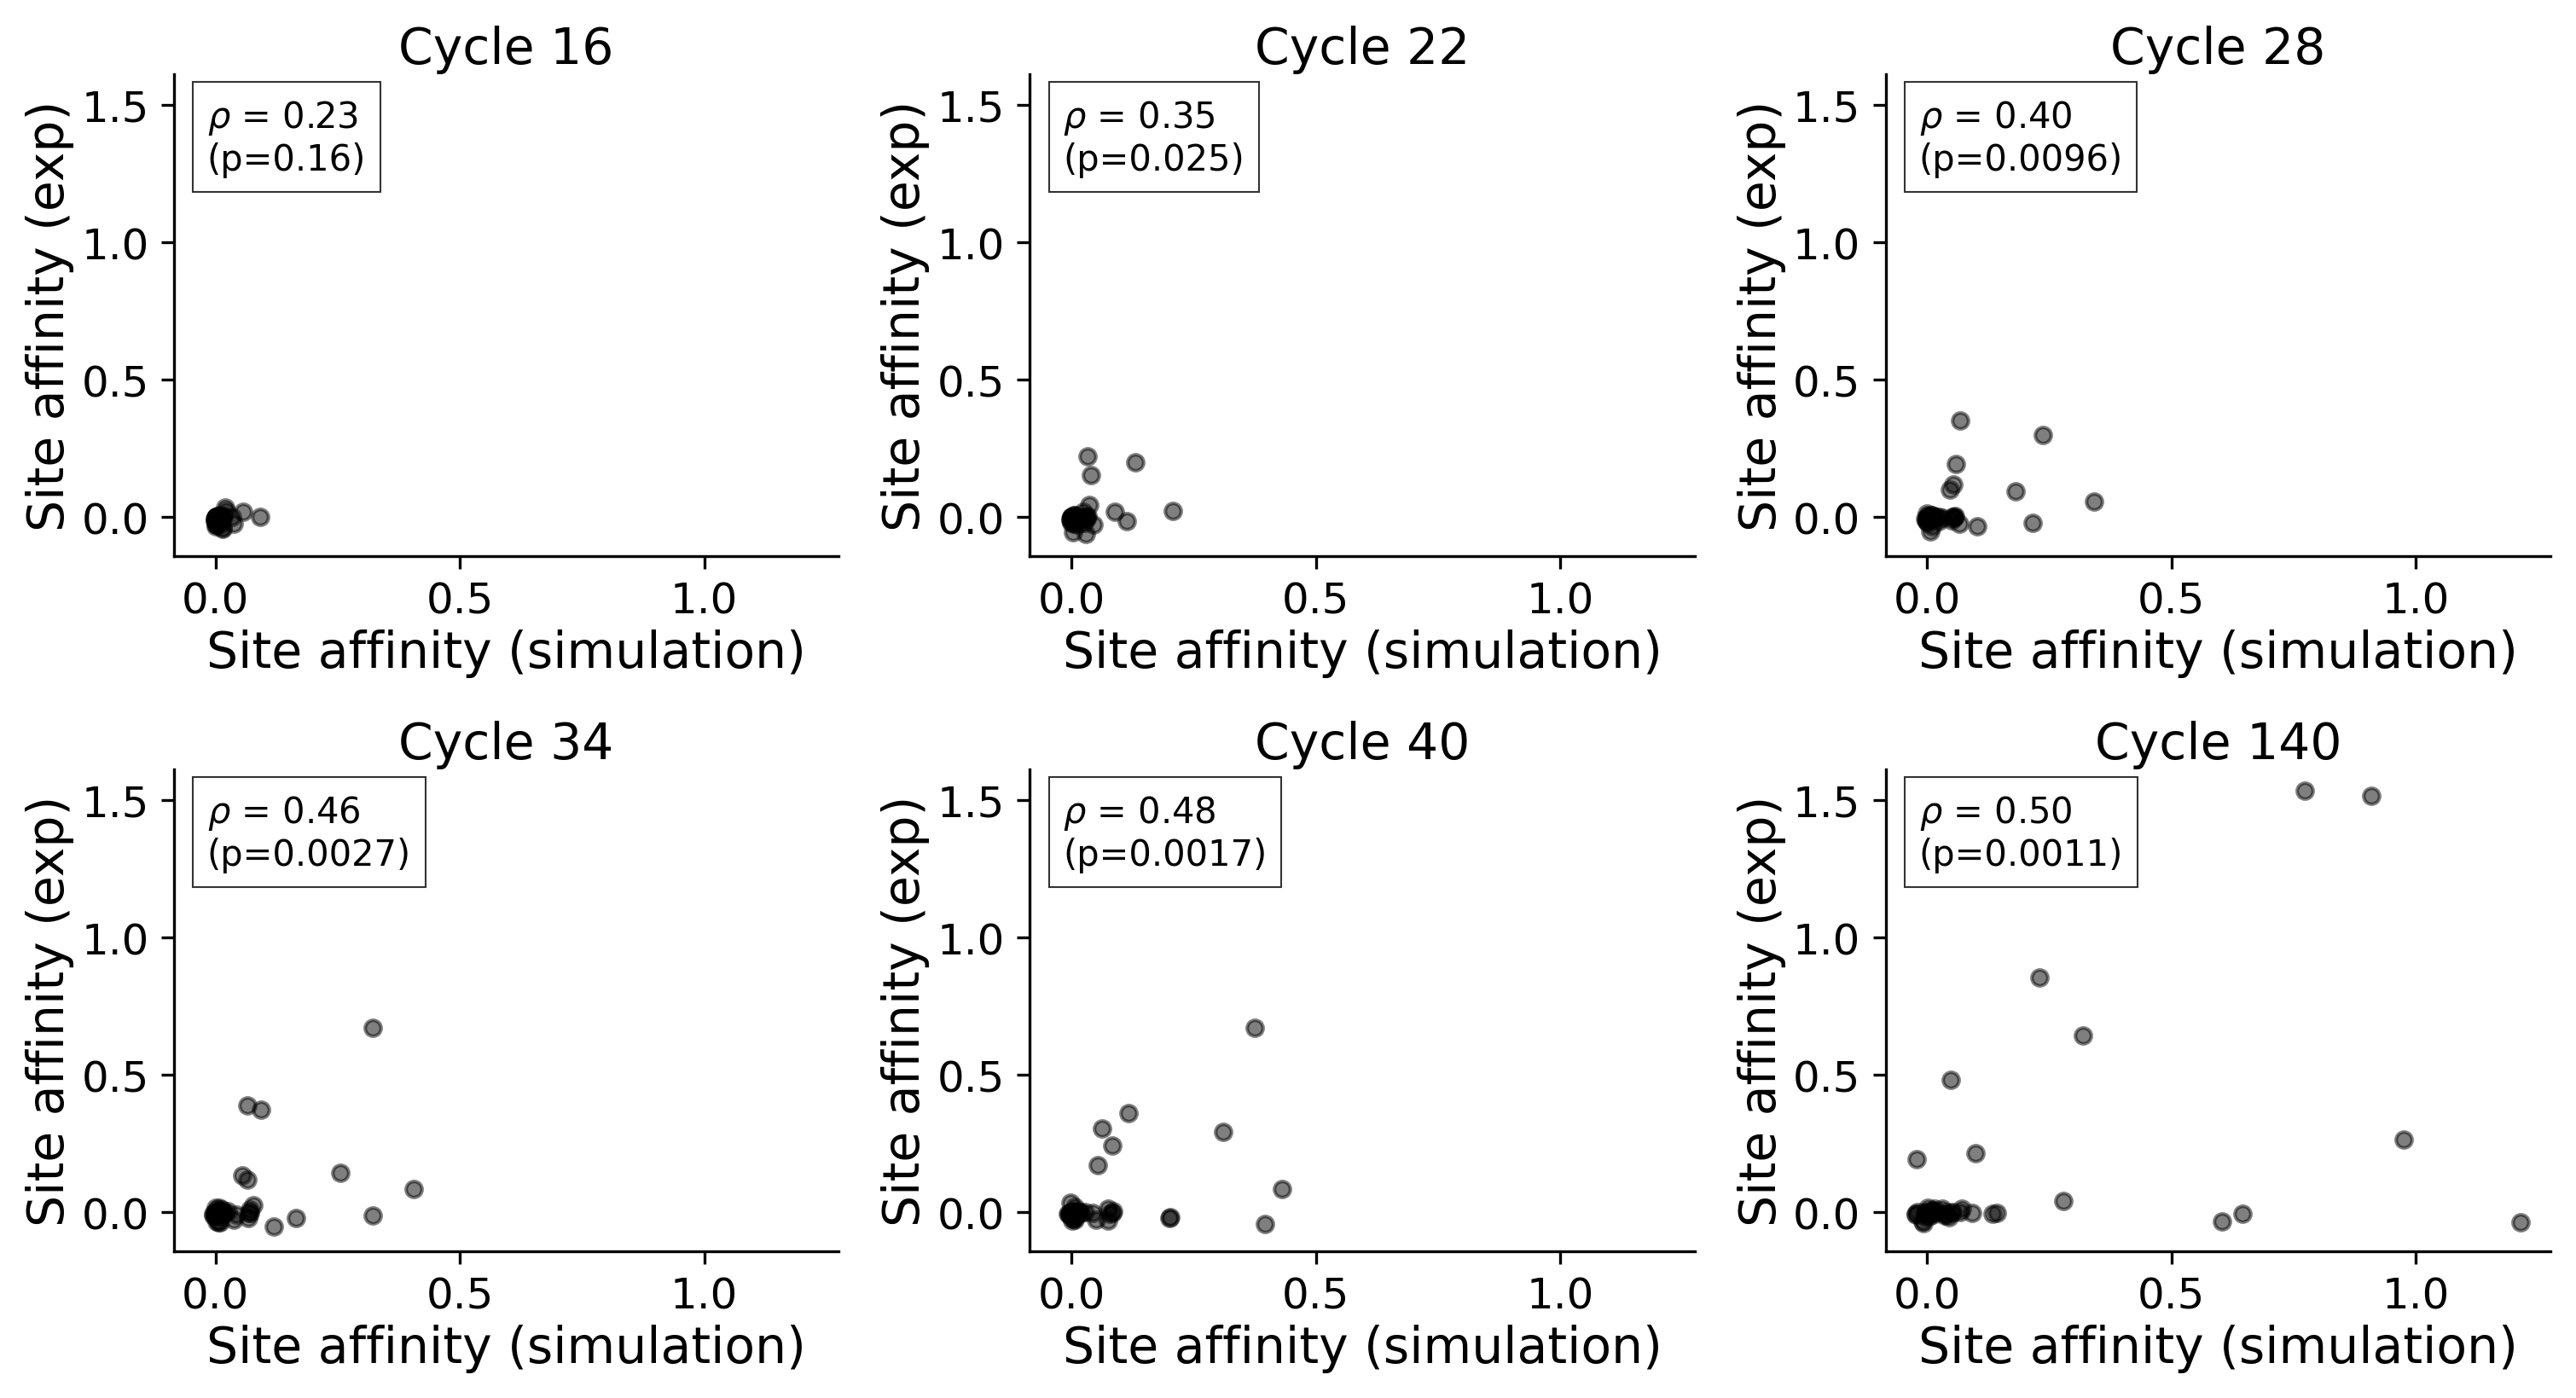

In [311]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
import pandas as pd

# Load data
df_out = pd.read_csv('../stochastic/mean_hi_stochastic.csv')
times = sorted(df_out["time"].unique())[1:]

# PRL figure style
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
# --- NEW: Calculate Global Limits for Same Scale ---
# 1. Get all X values (filtered as per your loop)
all_x_data = df_out[df_out["mean_hi"] != 0]["mean_hi"]
g_xlim = (all_x_data.min(), all_x_data.max())

# 2. Get all Y values to find global min/max
# We must replicate the data extraction logic to find the range of experimental data
all_y_vals = []
for t in times:
    # Filter data for time t to get positions
    sub = df_out[(df_out["time"] == t) & (df_out["mean_hi"] != 0)]
    positions = sub["position"].values
    
    # Match values from avg_by_time (Assuming avg_by_time is defined in your env)
    if len(positions) > 0:
        vals = avg_by_time.loc[avg_by_time["time"] == t, np.array(positions)]
        if not vals.empty:
            all_y_vals.extend(vals.iloc[0].values)

# Determine limits with a 5% margin padding
x_margin = (g_xlim[1] - g_xlim[0]) * 0.05
y_min, y_max = np.min(all_y_vals), np.max(all_y_vals)
y_margin = (y_max - y_min) * 0.05

final_xlim = (g_xlim[0] - x_margin, g_xlim[1] + x_margin)
final_ylim = (y_min - y_margin, y_max + y_margin)
# ---------------------------------------------------

# Arrange in grid: 3 plots per row
ncols = 3
nrows = int(np.ceil(len(times) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4*ncols, 2.8*nrows))
axes = np.atleast_2d(axes)  # always 2D array

for idx, t in enumerate(times):
    ax = axes[idx // ncols, idx % ncols]

    # Filter data for time t
    sub = df_out[(df_out["time"] == t) & (df_out["mean_hi"] != 0)]
    positions = sub["position"].values

    # Match values from avg_by_time
    avg_vals = avg_by_time.loc[avg_by_time["time"] == t, np.array(positions)]
    if not avg_vals.empty:
        avg_vals = avg_vals.iloc[0].values
    else:
        avg_vals = [0] * len(positions)

    # Scatter plot
    ax.scatter(sub["mean_hi"], avg_vals, s=20, c="black", alpha=0.5)
    
    # --- NEW: Apply Global Limits ---
    ax.set_xlim(final_xlim)
    ax.set_ylim(final_ylim)
    # --------------------------------
    
    ax.set_xlabel("Site affinity (simulation)", labelpad=2)
    ax.set_ylabel("Site affinity (exp)", labelpad=2)
    ax.set_title(f"Cycle {t}", pad=3)

    # Remove extra spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Spearman correlation
    if len(sub) > 1: # check to avoid error on empty/single point
        rho, pval = pearsonr(sub["mean_hi"], avg_vals)
        ax.text(
            0.05, 0.95,
            rf"$\rho$ = {rho:.2f}" + f"\n(p={pval:.2g})",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="black", linewidth=0.5)
        )

# Remove unused axes if times not divisible by ncols
for idx in range(len(times), nrows*ncols):
    fig.delaxes(axes[idx // ncols, idx % ncols])

plt.tight_layout(pad=1.0)
plt.show()